Dataset 'Employee-Attrition.csv' loaded successfully!
Dataset shape: (1470, 35)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470

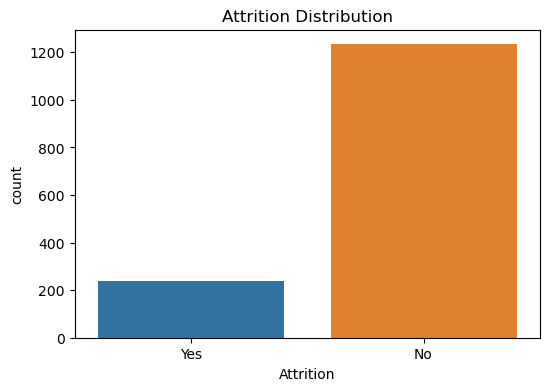

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


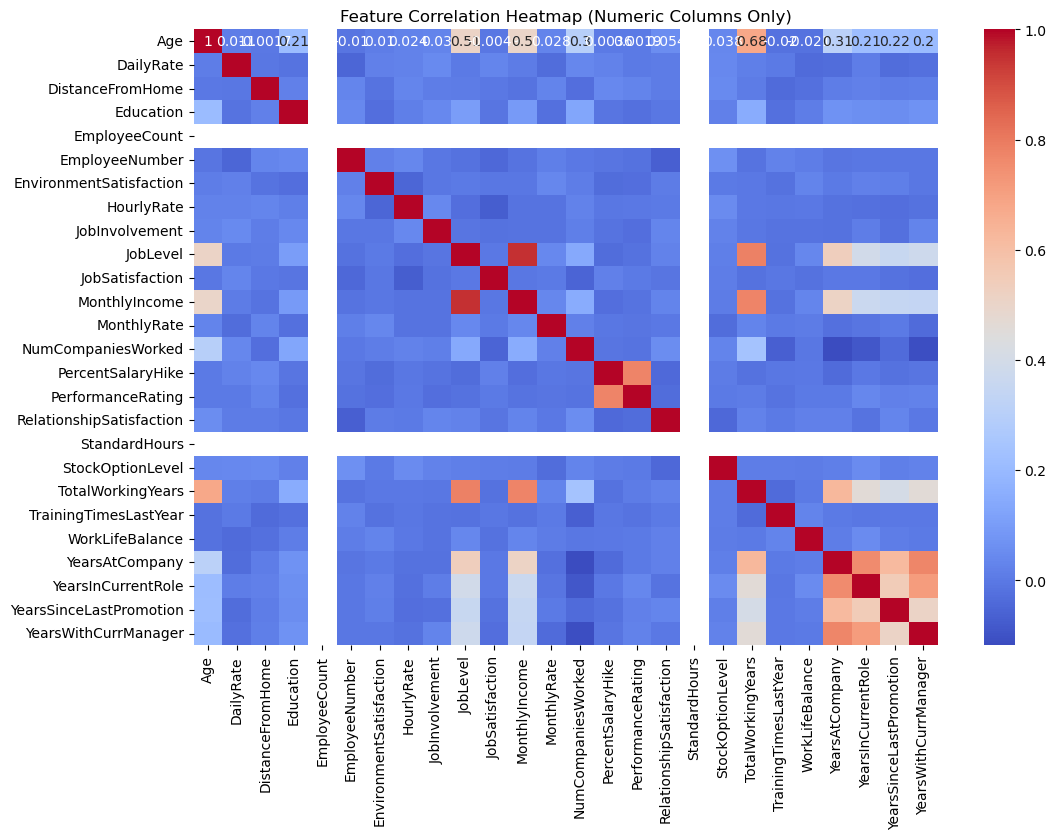


Logistic Regression Performance:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       255
           1       0.54      0.38      0.45        39

    accuracy                           0.87       294
   macro avg       0.72      0.67      0.69       294
weighted avg       0.86      0.87      0.87       294


Random Forest Performance:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294


Gradient Boosting Performance:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.65      0.28      0.39        39

    accuracy                           0.88       294
   macro avg       0.77      0.

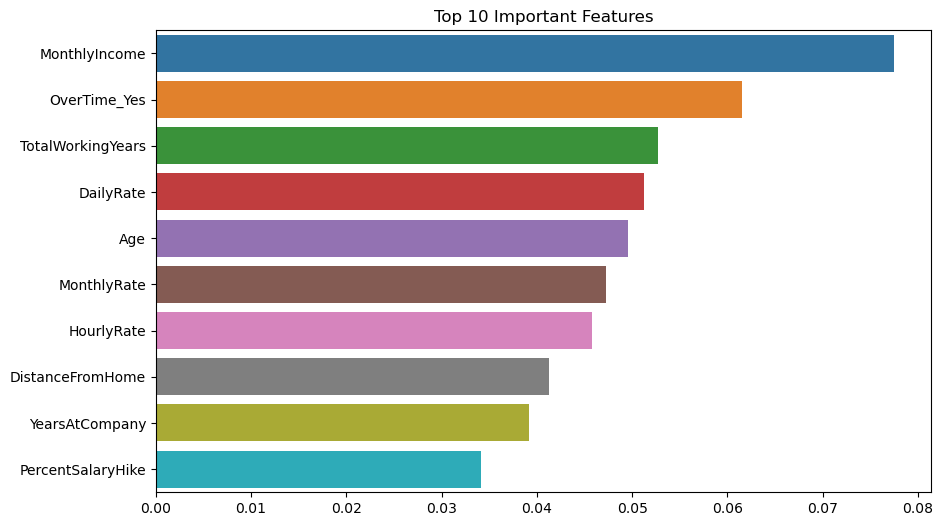


--- Key Insights ---
Top drivers of attrition: ['MonthlyIncome', 'OverTime_Yes', 'TotalWorkingYears', 'DailyRate', 'Age', 'MonthlyRate', 'HourlyRate', 'DistanceFromHome', 'YearsAtCompany', 'PercentSalaryHike']
This analysis identifies the most influential factors for employee attrition and compares multiple machine learning models to recommend predictive solutions for HR decision-making.


In [13]:
# HR_Attrition_Analysis.ipynb
# Fully updated and ready to run

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score

# -------------------------------
# 2. Load Dataset
# -------------------------------
# Assuming the CSV is in the same folder as this notebook
file_name = 'Employee-Attrition.csv'

try:
    data = pd.read_csv(file_name)
    print(f"Dataset '{file_name}' loaded successfully!")
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Make sure the CSV is in the same folder as this notebook.")

print("Dataset shape:", data.shape)
data.head()

# -------------------------------
# 3. Exploratory Data Analysis (EDA)
# -------------------------------
print("\n--- Dataset Info ---")
print(data.info())

print("\n--- Statistical Summary ---")
print(data.describe())

# Check missing values
print("\n--- Missing Values ---")
print(data.isnull().sum())

# Attrition distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=data)
plt.title('Attrition Distribution')
plt.show()

# Correlation heatmap for numeric columns only
numeric_data = data.select_dtypes(include=np.number)  # select only numeric columns

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Numeric Columns Only)")
plt.show()



# -------------------------------
# 4. Feature Engineering
# -------------------------------
# Convert target to binary
data['Attrition'] = data['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

# Binning 'YearsAtCompany' to reflect HR career stages
data['YearsAtCompany_Binned'] = pd.cut(
    data['YearsAtCompany'], 
    bins=[0, 2, 5, 10, 40], 
    labels=[0,1,2,3]
)

# Drop columns that are not predictive
X = data.drop(['Attrition', 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)
y = data['Attrition']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# -------------------------------
# 5. Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# 6. Model Building & Comparison
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    results[name] = {"Accuracy": acc, "F1-Score": f1, "ROC-AUC": roc}
    print(f"\n{name} Performance:\n", classification_report(y_test, y_pred))

# Compare results
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison ---")
print(results_df)

# -------------------------------
# 7. Feature Importance (Random Forest)
# -------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10])
plt.title("Top 10 Important Features")
plt.show()

# -------------------------------
# 8. Insights / Summary
# -------------------------------
print("\n--- Key Insights ---")
print("Top drivers of attrition:", feat_imp[:10].index.tolist())
print("This analysis identifies the most influential factors for employee attrition and compares multiple machine learning models to recommend predictive solutions for HR decision-making."
)

